# `find_invalid_pores`
Finds all pores that are either fully closed or that touch a face without spanning the domain. The result encodes the two cases as different integer values.

In [1]:
import matplotlib.pyplot as plt

import porespy as ps

ps.visualization.set_mpl_style()

The arguments and their defaults are:

In [2]:
import inspect

inspect.signature(ps.filters.find_invalid_pores)

<Signature (im: numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[~_ScalarT]], axis=None, conn: Literal['max', 'min'] = 'min')>

## `im`
A boolean image with `True` indicating the void phase. The output is an integer array: `1` marks closed pores and `2` marks surface pores.

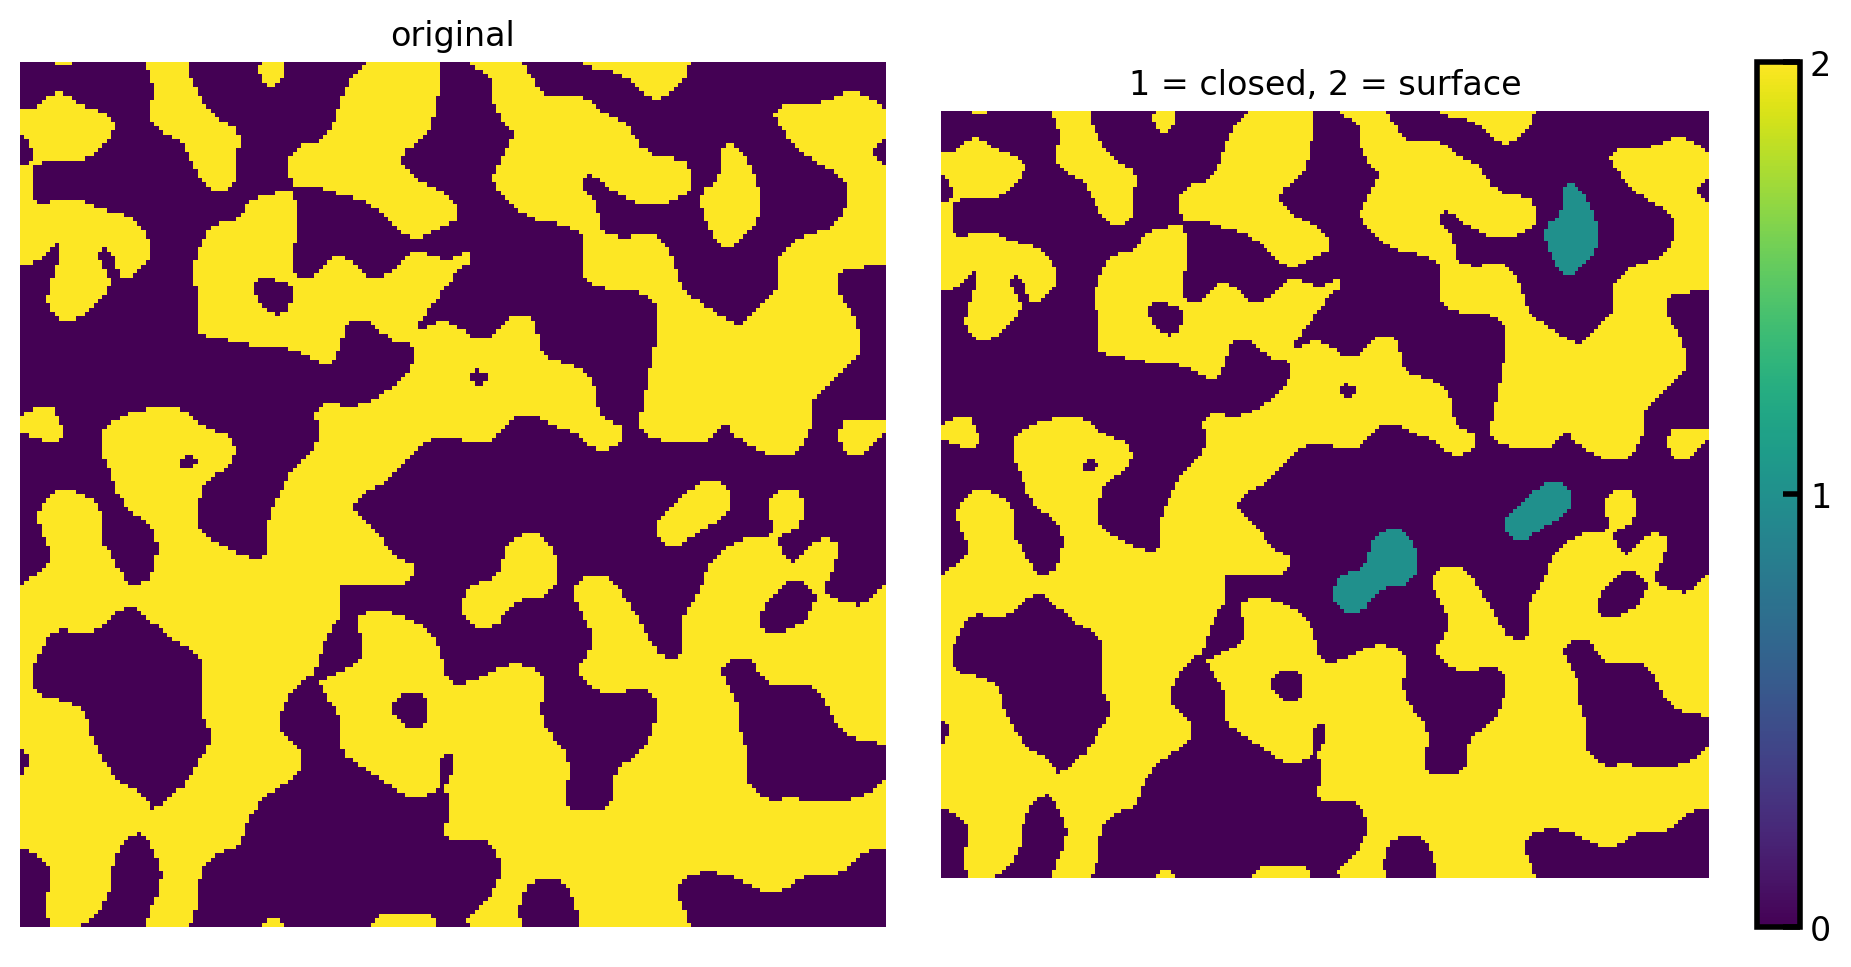

In [3]:
im = ps.generators.blobs(shape=[200, 200], porosity=0.5, seed=0)
invalid = ps.filters.find_invalid_pores(im=im)

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(im, origin='lower', interpolation='none')
ax[0].set_title('original')
ax[0].axis(False)
h = ax[1].imshow(invalid, origin='lower', interpolation='none')
ax[1].set_title('1 = closed, 2 = surface')
ax[1].axis(False)
fig.colorbar(h, ax=ax[1], ticks=[0, 1, 2]);

## `axis`
Restricts the surface-pore test to a single direction. Closed pores are not affected; only the set of surface pores changes.

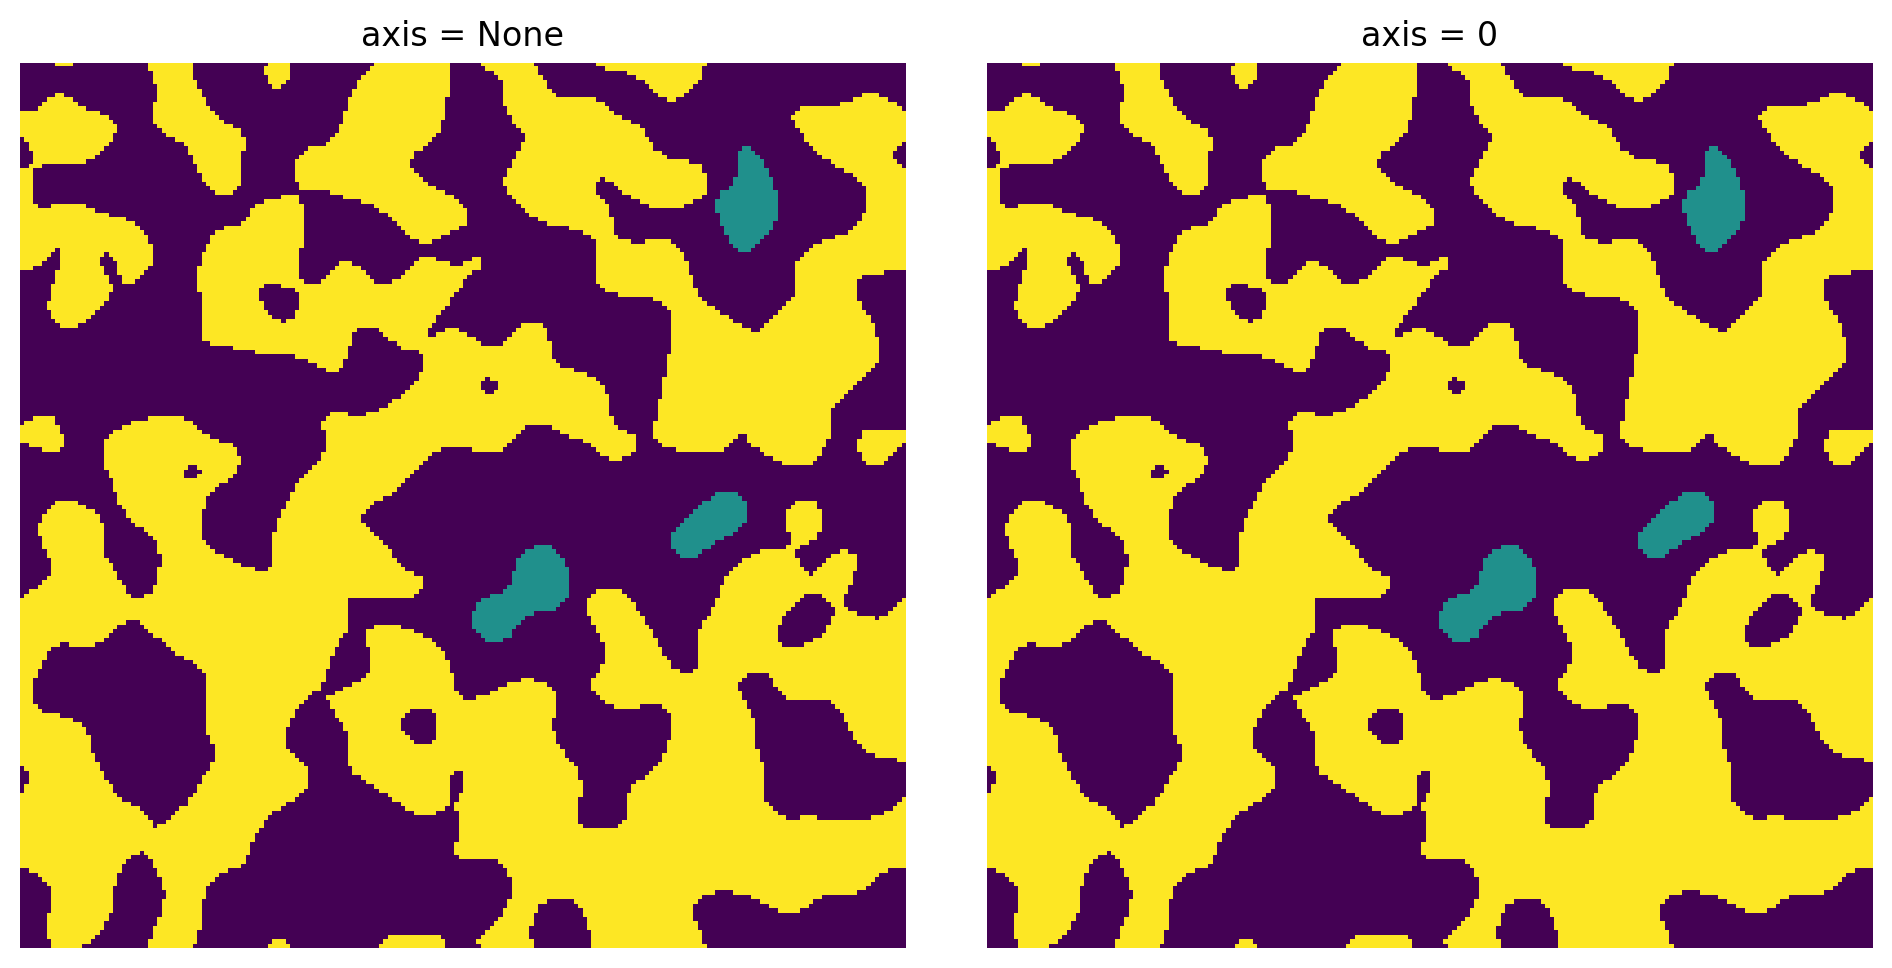

In [4]:
invalid_all = ps.filters.find_invalid_pores(im=im)
invalid_x = ps.filters.find_invalid_pores(im=im, axis=0)

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(invalid_all, origin='lower', interpolation='none')
ax[0].set_title('axis = None')
ax[0].axis(False)
ax[1].imshow(invalid_x, origin='lower', interpolation='none')
ax[1].set_title('axis = 0')
ax[1].axis(False);

## `conn`
Controls voxel connectivity, the same way as for `find_closed_pores` and `find_surface_pores`.

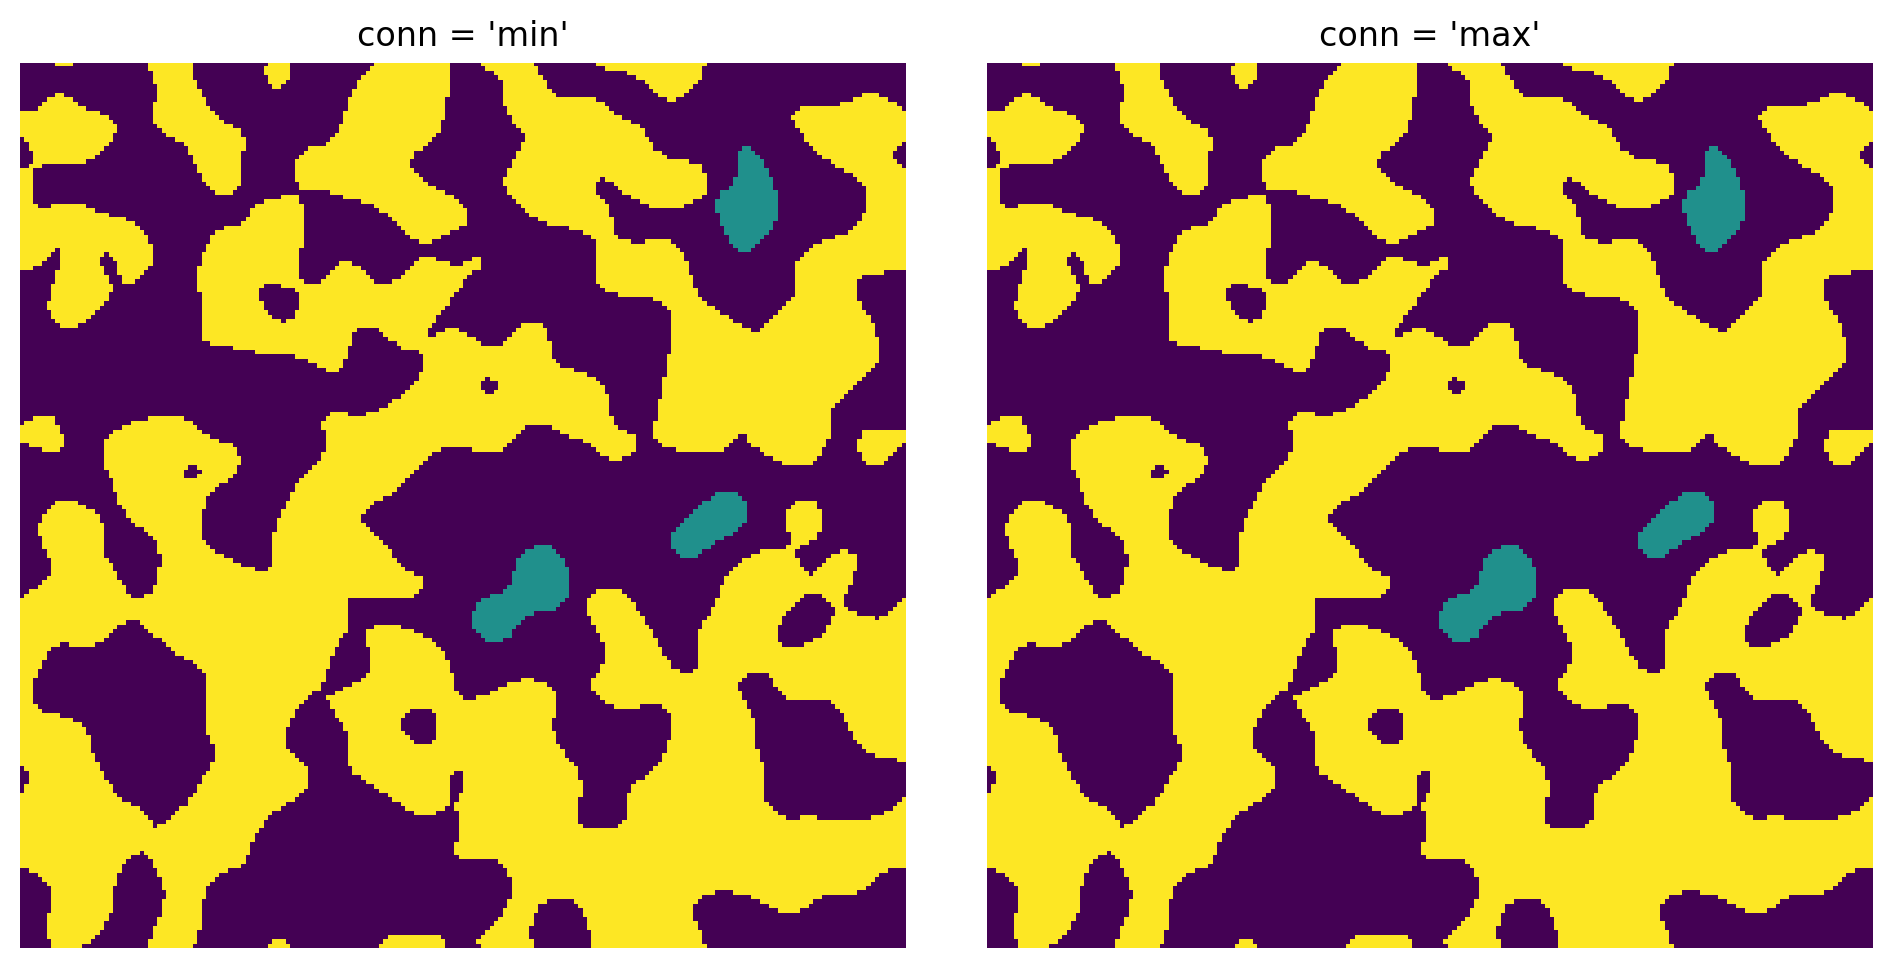

In [5]:
invalid_min = ps.filters.find_invalid_pores(im=im, conn='min')
invalid_max = ps.filters.find_invalid_pores(im=im, conn='max')

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(invalid_min, origin='lower', interpolation='none')
ax[0].set_title("conn = 'min'")
ax[0].axis(False)
ax[1].imshow(invalid_max, origin='lower', interpolation='none')
ax[1].set_title("conn = 'max'")
ax[1].axis(False);